# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [ ]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [ ]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [ ]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [ ]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


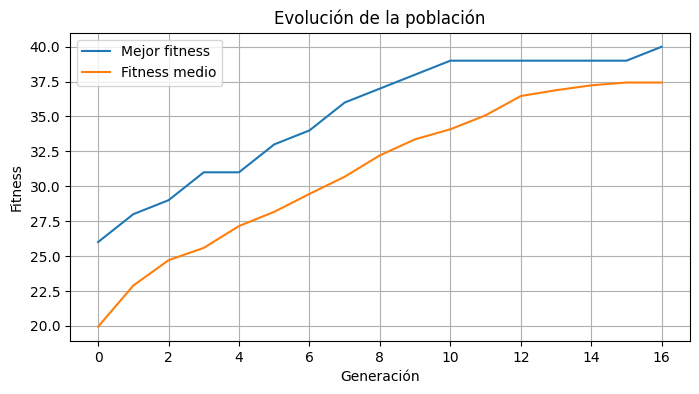

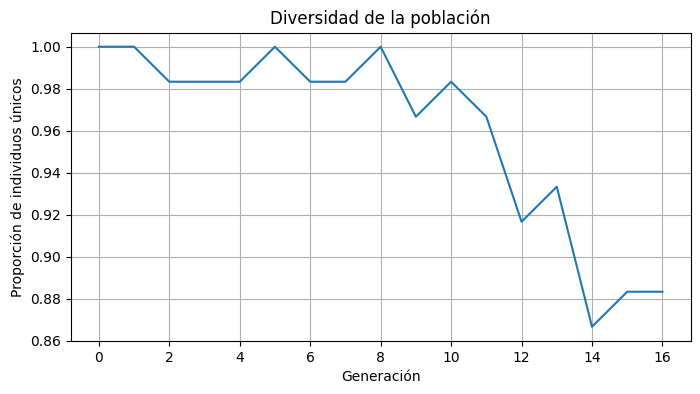

In [ ]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [ ]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [ ]:
def roulette_selection(population, rng):
    fitnesses = [fitness(ind) for ind in population]
    total_fitness = sum(fitnesses)

    if total_fitness == 0:
        probabilities = [1 / len(population)] * len(population)
    else:
        probabilities = [f / total_fitness for f in fitnesses]

    selected_individual = rng.choices(population, weights=probabilities, k=1)[0]
    return selected_individual.copy()

### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [ ]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []
    for i in range(len(parent1)):
        if rng.random() < 0.5:
            child1.append(parent1[i])
            child2.append(parent2[i])
        else:
            child1.append(parent2[i])
            child2.append(parent1[i])
    return child1, child2

### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

Frase objetivo: INTELIGENCIA ARTIFICIAL
Mejor frase encontrada: INTELIGENCIA ARTIFICIAL
Fitness: 23 / 23
Generaciones ejecutadas: 65


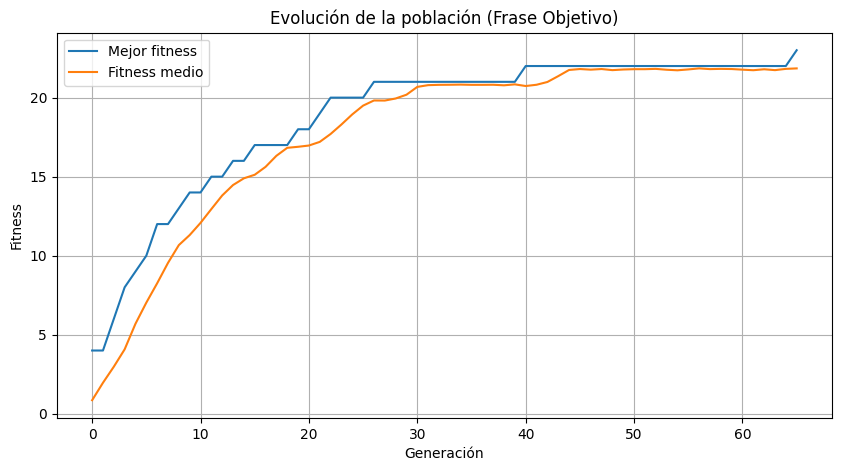

In [ ]:
TARGET_PHRASE = "INTELIGENCIA ARTIFICIAL"
ALPHABET = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ '

def create_individual_char(length, rng):
    return [rng.choice(ALPHABET) for _ in range(length)]

def fitness_char(individual):
    score = 0
    for i in range(len(individual)):
        if i < len(TARGET_PHRASE) and individual[i] == TARGET_PHRASE[i]:
            score += 1
    return score

def as_string_char(individual):
    return ''.join(individual)

def mutate_char(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(ALPHABET)
    return child

original_create_individual = globals().get('create_individual')
original_fitness = globals().get('fitness')
original_as_string = globals().get('as_string')
original_mutate = globals().get('mutate')

globals()['create_individual'] = create_individual_char
globals()['fitness'] = fitness_char
globals()['as_string'] = as_string_char
globals()['mutate'] = mutate_char


best_phrase, history_phrase = genetic_algorithm(
    chromosome_length=len(TARGET_PHRASE),
    population_size=200,
    generations=1000,
    crossover_rate=0.9,
    mutation_rate=0.01,
    tournament_size=5,
    elitism=True,
    seed=SEED
)

print('Frase objetivo:', TARGET_PHRASE)
print('Mejor frase encontrada:', as_string_char(best_phrase))
print('Fitness:', fitness_char(best_phrase), '/', len(TARGET_PHRASE))
print('Generaciones ejecutadas:', history_phrase[-1]['generation'])


generations_phrase = [h['generation'] for h in history_phrase]
best_values_phrase = [h['best'] for h in history_phrase]
mean_values_phrase = [h['mean'] for h in history_phrase]

plt.figure(figsize=(10, 5))
plt.plot(generations_phrase, best_values_phrase, label='Mejor fitness')
plt.plot(generations_phrase, mean_values_phrase, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población (Frase Objetivo)')
plt.legend()
plt.grid(True)
plt.show()


if original_create_individual: globals()['create_individual'] = original_create_individual
if original_fitness: globals()['fitness'] = original_fitness
if original_as_string: globals()['as_string'] = original_as_string
if original_mutate: globals()['mutate'] = original_mutate

### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado. R/ Sí, puede disminuir si no hay elitismo. El mejor fitness puede disminuir de una generación a otra porque el mejor individuo no tiene garantizada su supervivencia. Durante la selección, el cruce y la mutación pueden generarse nuevas poblaciones en las que ninguna solución sea tan buena como la mejor solución anterior. Con elitismo, el mejor individuo se copia directamente a la siguiente generación, por lo que el mejor fitness solo puede mantenerse o aumentar.

## Preguntas de cierre

1. ¿Qué papel cumple la población que no existe en Hill Climbing? R/ La población permite mantener múltiples soluciones y explorar diferentes espacios de busqueda. Esto nos brinda mayor diversidad y reduce el riesgo de que la búsqueda quede atrapada en un máximo o mínimo local como suele pasar en hill climbing donde normalmente se trabaja con una única solución.

2. ¿Por qué el cruce no garantiza hijos mejores que sus padres? R/ El cruce no garantiza hijos mejores porque al combinar los cromosomas de los padres puede destruir combinaciones de genes que contribuían a un buen fitness. Dependiendo del punto o método de cruce, los hijos pueden ser mejores, iguales o incluso peores que sus padres.
R/La convergencia prematura ocurre cuando la población pierde diversidad demasiado rápido y los individuos se vuelven muy similares antes de encontrar el óptimo global (en muy corto tiempo). Como consecuencia, el algoritmo deja de explorar suficientemente diferentes regiones del espacio de búsqueda y puede quedar atrapado en una solución subóptima.
3. ¿Qué significa convergencia prematura? R/ La convergencia prematura ocurre cuando la población pierde diversidad demasiado rápido y los individuos se vuelven muy similares antes de encontrar el óptimo global. Como consecuencia, el algoritmo deja de explorar suficientemente otras regiones del espacio de búsqueda y puede quedar atrapado en una solución subóptima.
4. ¿Qué parámetros controlan la exploración?
R/Los principales parámetros que controlan la exploración son la tasa de mutación, el tamaño de la población, la presión de selección. Un ejemplo es el tamaño del torneo y la tasa de cruce. Una mayor mutación y una población más diversa favorecen la exploración, mientras que una presión de selección muy alta puede acelerar la explotación y aumentar el riesgo de convergencia prematura.